# Netimpact

- *Input = demand*
- *Output = production*

#### Opmerkingen vooraf

- Dit werkt helemaal (voor input). In de mapping bestaat nog geen *output*.
    - In de mapping van *input* worden niet alle keys meegenomen, waarom is dat zo? 
    - Achterliggende vraag: moet dan alles bij output wel worden meegenomen? Welke dan wel/niet? (Totaal van vraag & aanbod is geen 0)
- In conceptversie wordt *aanbod* verwerkt

#### Doel script: 
 1. Identificatie van piekmoment (zowel vraag als aanbod) ✅
 2. Doorsnede op piekmoment (zowel vraag als aanbod) ✅
 3. Visualisaties
    - Grafiek 1: Maximale piekvraag (totale vraag per uur) 
        - Vraag 🟧--> aanpassen naar *alle* keys
        - Aanbod ⭕️
    - Grafiek 2: Piekvraag uitgesplitst naar sectoren
        - Vraag ✅
        - Aanbod ⭕️

Een leeg scenario voor Zuid-Holland en het NBNL KM-scenario voor Zuid-Holland zijn als uitgangspunt genomen.

KM-scenario Zuid-Holland: https://pro.energytransitionmodel.com/scenarios/1365369



#### **User input**:
- Geef bij `3. File paths & mapping` aan welke curves je wil gebruiken.

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### 2. Functions 

- Voor nu moeten de curves 'met de hand' worden gedownload uit de front-end, het idee is om dit later via pyETM te koppelen.
- Curves staan in de folder `scenario-tools/tests/netimpact/curves`

In [2]:
def read_mapping_file(mapping_filepath):
    """Read mapping CSV file into a DataFrame."""
    return pd.read_csv(mapping_filepath)

def clean_column_names(df):
    """Remove '.input (MW)' from column names."""
    df.columns = df.columns.str.replace(r'\.input \(MW\)', '', regex=True)
    return df

def get_max_input(df):
    """Return the row with the maximum total input and sum column."""
    df['sum'] = df.iloc[:, 1:].sum(axis=1)
    idx_max = df['sum'].idxmax()
    return df.loc[[idx_max]], idx_max

def map_filters(df, mapping_df):
    """Map keys to their filters based on mapping DataFrame."""
    mapping_df['key_clean'] = mapping_df['key'].str.replace(r'\.input \(MW\)', '', regex=True)
    df['filter'] = df.index.map(
        lambda key: mapping_df.loc[mapping_df['key_clean'] == key, 'filter'].values[0]
        if key in mapping_df['key_clean'].values else 'Unknown'
    )
    return df

def process_file(filepath, keys_to_keep, mapping_df):
    """Read a CSV file and process it for max input and filters."""
    df = pd.read_csv(filepath)
    df = df[[col for col in df.columns if col in keys_to_keep or col.lower() == 'time']].copy()
    df_input = clean_column_names(df.filter(regex=r"(?i)(input|^time$)"))
    max_row_df, idx_max = get_max_input(df_input)
    df_transposed = max_row_df.set_index('Time').T.drop(index='sum')
    df_transposed = map_filters(df_transposed, mapping_df)
    return df_transposed, idx_max, max_row_df['Time'].values[0], max_row_df['sum'].values[0]


### 3. File paths & mapping

In [3]:
# Paths
mapping_file_path = "mappings/mapping_input.csv"
curve_filepaths = [
    'curves/ZH_empty_merit_order.csv',
    'curves/ZH_KM_merit_order.csv'
]

# Read mapping
mapping_df = read_mapping_file(mapping_file_path)
keys_to_keep = mapping_df['key'].tolist()


### 4. Process all files (data preparation)

In [4]:
# Store processed data
processed_data = []

for filepath in curve_filepaths:
    df_transposed, idx_max, time_of_max, max_value = process_file(filepath, keys_to_keep, mapping_df)
    processed_data.append({
        'filepath': filepath,
        'df_transposed': df_transposed,
        'idx_max': idx_max,
        'time_of_max': time_of_max,
        'max_value': max_value
    })
    print(f"{filepath.split('/')[-1]} - Max: {max_value:.1f} MW at {time_of_max}")


ZH_empty_merit_order.csv - Max: 4974.2 MW at 2030-12-07 09:00
ZH_KM_merit_order.csv - Max: 19813.7 MW at 2050-01-31 12:00


### 5. Plot maximum peak per file

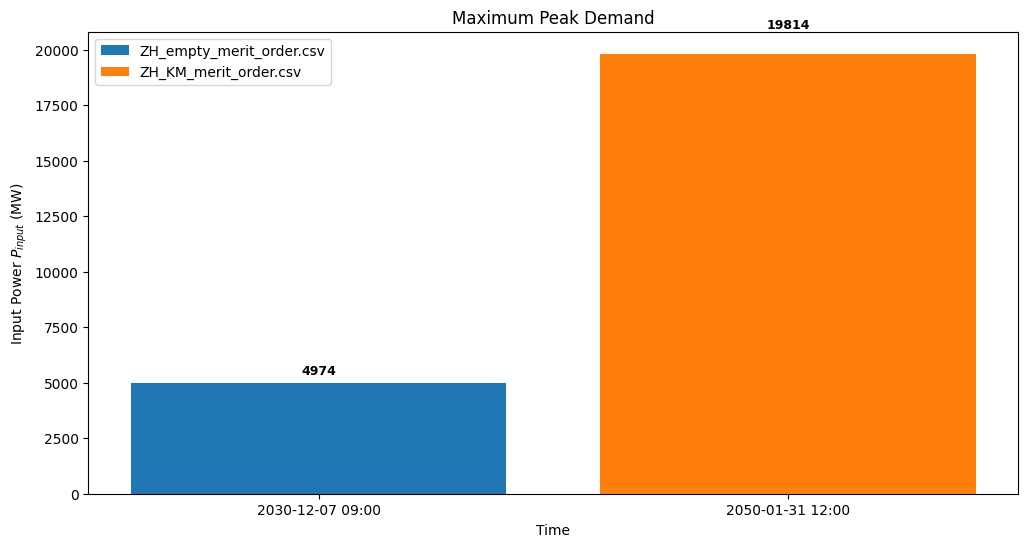

In [5]:
plt.figure(figsize=(12, 6))

for data in processed_data:
    df_transposed = data['df_transposed']
    df_numeric = df_transposed.drop(columns='filter').astype(float)
    
    time_of_max = data['time_of_max']
    max_value = data['max_value']
    
    y = df_numeric.sum(axis=0).values
    x = [time_of_max]
    
    plt.bar(x, y, bottom=np.cumsum(np.insert(y[:-1], 0, 0)), label=data['filepath'].split('/')[-1])
    plt.text(time_of_max, max_value * 1.05, f'{max_value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylabel('Input Power $P_{input}$ (MW)')
plt.xlabel('Time')
plt.title('Maximum Peak Demand')
plt.legend()
plt.show()


### 6. Plot maximum peak per sector

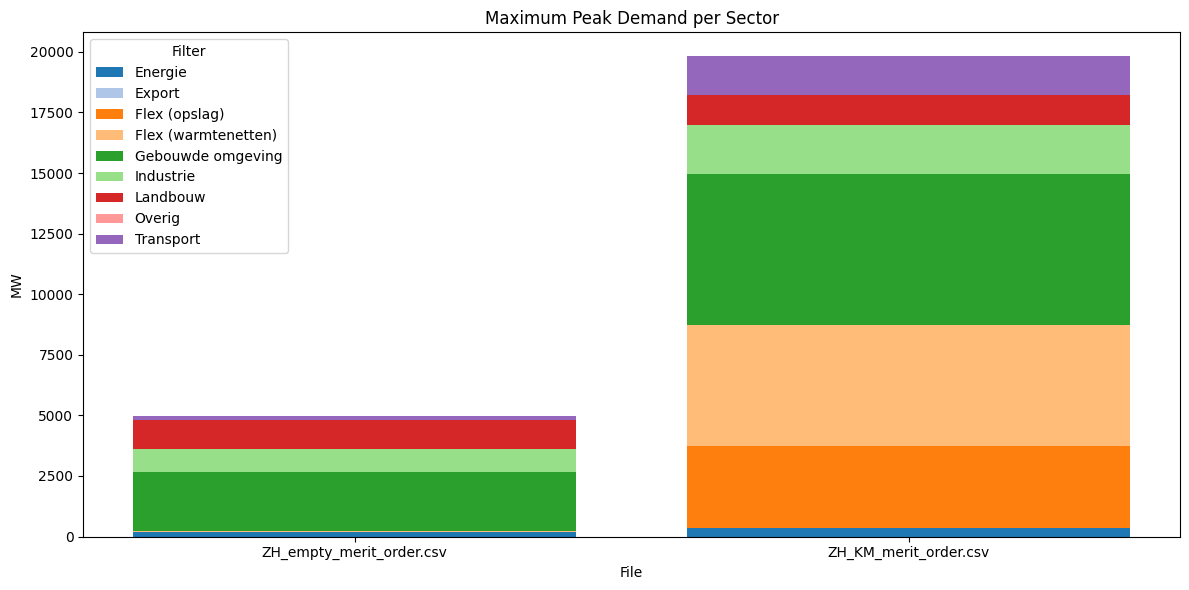

In [6]:
# Gather all unique filters
all_filters = set()
for data in processed_data:
    all_filters.update(data['df_transposed']['filter'].unique())

# Assign colors
colors = plt.cm.tab20.colors
filter_colors = {filt: colors[i % len(colors)] for i, filt in enumerate(sorted(all_filters))}

plt.figure(figsize=(12, 6))
x_pos = np.arange(len(processed_data))

for i, data in enumerate(processed_data):
    df_transposed = data['df_transposed']
    grouped = df_transposed.drop(columns='filter').groupby(df_transposed['filter']).sum()
    
    bottom = 0
    for filter_name, row in grouped.iterrows():
        plt.bar(x_pos[i], row.iloc[0], bottom=bottom, color=filter_colors[filter_name],
                label=filter_name if i == 0 else "")
        bottom += row.iloc[0]

plt.xticks(x_pos, [d['filepath'].split('/')[-1] for d in processed_data])
plt.ylabel('MW')
plt.xlabel('File')
plt.title('Maximum Peak Demand per Sector')
plt.legend(title='Filter')
plt.tight_layout()
plt.show()


### 7. Export processed data to csv-file

In [7]:
processed_input_data = []
export_rows = []

for filepath in curve_filepaths:
    # Process each CSV file and get the transposed max row with additional info
    df_transposed, idx_max, time_of_max, max_value = process_file(filepath, keys_to_keep, mapping_df)
    
    # Store processed data for further use (e.g., plotting)
    processed_input_data.append({
        'filepath': filepath,
        'df_transposed': df_transposed,
        'idx_max': idx_max,
        'time_of_max': time_of_max,
        'max_value': max_value
    })
    
    # Select only numeric columns for summing
    numeric_cols = df_transposed.select_dtypes(include=np.number).columns
    
    # Add one row per key to the export list
    for key in df_transposed.index:
        export_rows.append({
            'file': filepath.split('/')[-1],
            'time_of_max': time_of_max,
            'key': key,
            'value': df_transposed.loc[key, numeric_cols].sum(),  # sum only numeric values
            'filter': df_transposed.loc[key, 'filter']
        })
    
    # Print maximum input for the current file
    print(f"{filepath.split('/')[-1]} - Max input: {max_value:.1f} MW at {time_of_max}")

# Create a DataFrame from the export list and sort it
export_df = pd.DataFrame(export_rows)
export_df = export_df.sort_values(by=['file', 'filter', 'key']).reset_index(drop=True)

# Export the DataFrame to CSV
export_df.to_csv('output/max_input_summary.csv', index=False)

print("CSV export created: max_input_summary.csv")


ZH_empty_merit_order.csv - Max input: 4974.2 MW at 2030-12-07 09:00
ZH_KM_merit_order.csv - Max input: 19813.7 MW at 2050-01-31 12:00
CSV export created: max_input_summary.csv
